### Practice with data in pandas

We'll often load data using pandas, a library that provides data manipulation and analysis tools. It also makes it very easy to work with .csv files without having to mess around with python string methods. 

In this exercise, you'll use pandas to open a spreadsheet with information about the class roster, take a look at the information already listed, and add some more info to it. 

Make sure you get the most up-to-date version of the spreadsheet by running a "git pull," as shown in Studio 2, to get the newest version from the repository before starting work. You'll be updating that version yourself as part of this notebook. 



First, let's try peeking at the first few lines of the file with built-in python methods, just to see what we have.

In [44]:
file = open('../Data/class_list.csv')
file.readlines()[0:3]

['#Name (string),In our class? (Bool), favorite number (double), Preferred mode of contact for group work (string), Contact info (string)\n',
 'Name,In_448,Favorite_Num,Contact_Mode,Contact_Info\n',
 'Julieta Gruszko,TRUE,13,E-mail,jgruszko@unc.edu\n']

You should see that the first line is a comment (indicated by the # symbol) telling us the contents of each column, the second line is the column titles, and the 3rd line is the first instance.

Pandas is very good at parsing csv files and gettign them into memory. The fundamental way pandas handles data is as a $\textbf{data frame}$, which is basically a table. The columns are the values stored for each entry, and the rows are the instances/data entries. Columns can have different types.

Here, we'll use an optional extra argument to tell pandas that lines that start with a '#' are a comment; it'll skip adding them to the data frame. That way we can use comment lines to include extra information in our data files. 

In [45]:
import pandas as pd

In [46]:
classlist = pd.read_csv('../Data/class_list.csv', comment='#')

We can see the data frame like this:

In [47]:
display(classlist)

,Name,In_448,Favorite_Num,Contact_Mode,Contact_Info
0,Julieta Gruszko,True,13,E-mail,jgruszko@unc.edu
1,Santa Claus,False,25,Letter,santa@north.pole
2,Taylor Swift,False,13,Instagram,@taylorswift
3,Marie Curie,False,88,Medium,NaN


If the data set has gotten long, it can be useful to look just at the head or tail of it:

In [48]:
classlist.head()

,Name,In_448,Favorite_Num,Contact_Mode,Contact_Info
0,Julieta Gruszko,True,13,E-mail,jgruszko@unc.edu
1,Santa Claus,False,25,Letter,santa@north.pole
2,Taylor Swift,False,13,Instagram,@taylorswift
3,Marie Curie,False,88,Medium,NaN


You can see more about the dataframe with the info attribute, especially if you set verbose to "True."

In [49]:
classlist.info(verbose = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Name          4 non-null      object
 1   In_448        4 non-null      bool  
 2   Favorite_Num  4 non-null      int64 
 3   Contact_Mode  4 non-null      object
 4   Contact_Info  3 non-null      object
dtypes: bool(1), int64(1), object(3)
memory usage: 264.0+ bytes


Are there any null values in our class list dataframe?

>Yes. NaN is supposed to be a null value

You can see the documentation for the dataframe here: https://pandas.pydata.org/docs/reference/frame.html

Like in numpy, the shape of the dataframe is one of its attributes. As always, we access attributes by name with this syntax:

In [50]:
classlist.shape

(4, 5)

Be careful though! The size attribute has something different in it. Can you figure out (using the documentation and by taking a look at it), what it is?

>The size attribute does not count the column that counts the entries

There are many other useful attributes. Two of these that we'll look at return types that are specific to pandas: 
- the $\texttt{index}$ attribute stores the index start, stop, and step size of the rows in the table. The return type here is RangeIndex (https://pandas.pydata.org/docs/reference/api/pandas.RangeIndex.html), which has $\texttt{start}$, $\texttt{stop}$, and $\texttt{step}$ attributes of its own.
- the $\texttt{columns}$ attribute stores the list of all the column names, as return type Index (https://pandas.pydata.org/docs/reference/api/pandas.Index.html), which is an ordered list. You can access the values as a numpy array as shown, or use brackets to get a single value, as usual.

In [51]:
indexes = classlist.index
print(indexes)
cols = classlist.columns
print(cols)
print(cols.array)
print(cols[1]) #print the column name of the 1st column (0 indexing used as usual, of course)
print(cols[1:3]) #print the column names of the 1st through 3rd columns (inclusive of the first index, up to but not including the second index, again as usual)


RangeIndex(start=0, stop=4, step=1)
Index(['Name', 'In_448', 'Favorite_Num', 'Contact_Mode', 'Contact_Info'], dtype='object')
<NumpyExtensionArray>
['Name', 'In_448', 'Favorite_Num', 'Contact_Mode', 'Contact_Info']
Length: 5, dtype: object
In_448
Index(['In_448', 'Favorite_Num'], dtype='object')


We'll often select a subset of the instances (e.g. for a training set), which you can do by selecting by index:

In [52]:
classlist.iloc[0] #select all the columns for a single instance
classlist.iloc[0:3] #select all the columns for the first 3 instances
classlist.iloc[0:3, 0] # select the first column for the first 3 instances

0    Julieta Gruszko
1        Santa Claus
2       Taylor Swift
Name: Name, dtype: object

We'll also often drop a column entirely (e.g. when a column isn't a feature or a label). We can use this with the convenient "drop" function. 

In [53]:
classlist2 = classlist.drop("Contact_Info", axis=1) #drop a column by label. The "axis = 1" tells the drop that we're dropping a column, not a row
classlist2

,Name,In_448,Favorite_Num,Contact_Mode
0,Julieta Gruszko,True,13,E-mail
1,Santa Claus,False,25,Letter
2,Taylor Swift,False,13,Instagram
3,Marie Curie,False,88,Medium


We can see a summary of the values contained in numerical columns like this:

In [54]:
classlist.describe()

,Favorite_Num
count,4.000000
mean,34.750000
std,35.947879
min,13.000000
25%,13.000000
50%,19.000000
75%,40.750000
max,88.000000


We can select values from a single column with a few different methods, shown here.

In [55]:
classlist['Name']

0    Julieta Gruszko
1        Santa Claus
2       Taylor Swift
3        Marie Curie
Name: Name, dtype: object

In [56]:
classlist.Name

0    Julieta Gruszko
1        Santa Claus
2       Taylor Swift
3        Marie Curie
Name: Name, dtype: object

Using this method, plot a histogram of the values found in the "favorite number" column. You'll need to import matplotlib and matplotlib.pyplot to use its histogramming tools. Don't forget to add axis labels!

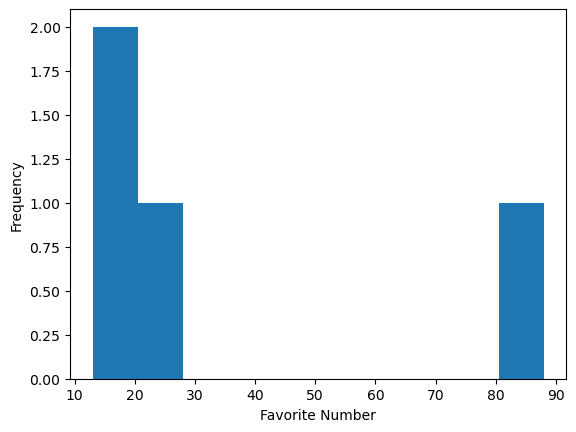

In [57]:
# Your histogram code here
import matplotlib.pyplot as plt

plt.hist(classlist.Favorite_Num)
plt.xlabel("Favorite Number")
plt.ylabel("Frequency");

We can filter our dataframe by the value of the columns. For example:

In [58]:
classlist[classlist['In_448']] #If we have a boolean column, we can just use the column context as the filter

,Name,In_448,Favorite_Num,Contact_Mode,Contact_Info
0,Julieta Gruszko,True,13,E-mail,jgruszko@unc.edu


In [59]:
classlist[classlist['Favorite_Num']<20] #For a numerical value, we can compare to some other value and get a boolean, which can then be used as a filter. 

,Name,In_448,Favorite_Num,Contact_Mode,Contact_Info
0,Julieta Gruszko,True,13,E-mail,jgruszko@unc.edu
2,Taylor Swift,False,13,Instagram,@taylorswift


Using the filtering approach shown above, remake your histogram just for people who are actually in PHYS 448.

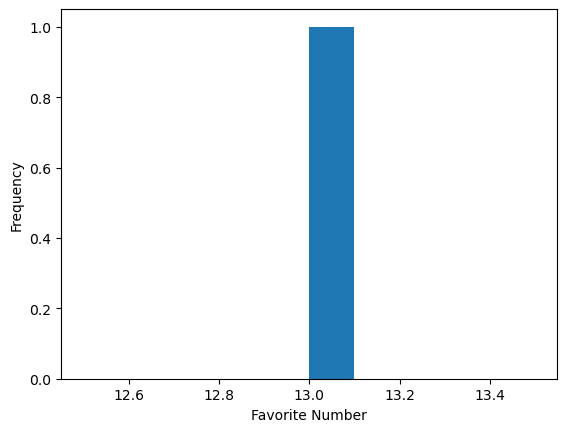

In [60]:
# Plotting code here
plt.hist(classlist[classlist['In_448']].Favorite_Num)
plt.xlabel("Favorite Number")
plt.ylabel("Frequency");

Take a look at the pandas documentation and try at least one new thing with the dataframe that isn't demonstrated above, and explain what you did.

In [61]:
# code to try something new
classlist.insert(3, "Favorite_Color", ['red', 'orange', 'yellow', 'green'])
classlist

,Name,In_448,Favorite_Num,Favorite_Color,Contact_Mode,Contact_Info
0,Julieta Gruszko,True,13,red,E-mail,jgruszko@unc.edu
1,Santa Claus,False,25,orange,Letter,santa@north.pole
2,Taylor Swift,False,13,yellow,Instagram,@taylorswift
3,Marie Curie,False,88,green,Medium,NaN


Your explanation:

>Insert a new column and populate it with people's favorite colors

Finally, we'll add a new instance to the table. 

There are two ways to add a row: you can add a single row directly at a location (the index after the $\texttt{stop}$ index, to add it to the end), or you can build a new dataframe with the same columns, and concatenate the two. The second of these is more generally useful, so we'll use that. 

Fill in the fields below with your own information to add yourself to the table. All of the students in the class will see this, so only add info you want to share. To make this table useful, please enter your preferred contact mode and contact info for future work on your group project. If you want to leave a field blank, you can enter "NA" or "NaN" and pandas will recongize it. 

Feel free to add an extra fake person - keep it workplace-appropriate! With Git, I can see exactly who added each line ;)

In [62]:
new_row = {'Name': 'Henry Holland', 'In_448': True, 'Favorite_Num': 20, 'Contact_Mode': 'Text', 'Contact_Info': '828-747-8542'} # fill in the columns to add yourself. If you want to add an extra fake person, you can make these fields arrays (e.g. 'Name': [name1, name2]) instead of single values.

new_row_df = pd.DataFrame([new_row])

classlist = pd.concat([classlist, new_row_df], ignore_index=True)

Take a look at the result:

In [63]:
classlist

,Name,In_448,Favorite_Num,Favorite_Color,Contact_Mode,Contact_Info
0,Julieta Gruszko,True,13,red,E-mail,jgruszko@unc.edu
1,Santa Claus,False,25,orange,Letter,santa@north.pole
2,Taylor Swift,False,13,yellow,Instagram,@taylorswift
3,Marie Curie,False,88,green,Medium,NaN
4,Henry Holland,True,20,NaN,Text,828-747-8542


Once you've modified the class list, commit the changes to the class_list.csv file (but not the changes to any other files!). Then in studio, I'll show you how these new commits are pushed to the remote version of the repository. 


Step by step instructions:
- Open the "source control" tab in the activities file and then open the "changes" drop-down section.
- You should see the class_list.csv file listed as one of those that changed. There may be other changes as well, depending on where you've been saving your studio and homework notebooks!
- Hovering over the file you want to change (class_list.csv), you should see a "+" appear. Click it to stage the changes. This means you're adding those changes to list of changes to be committed. Don't add/stage any other changes. 
- Click the button that says "Commit." When you do this, VS Code will open a file that has details on the changes you're committing. 
- The top row of that file must contain a "commit message" that gives a description of what change you made. This is how everyone else working on the code can follow what you've done. Write a message in the file, then press the check box (next to the file name in the top tabs) to save and close the file. 
- Now your commit should be complete. If you have the "Graph" drop down open in the Source Control tab, you'll see your new commit message appear there. 


### Acknowledgement Statement
(fill in if needed)